# Programme Title:	Diploma in Predictive Analytics (Summer 2026)
# Module Title(s):	Predictive Analytics

## Lecturer: Taufique Ahmed
### Johanna Riquelme

## Lab 5 Task 1 "Naive Bayes classifier "

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
#Read the dataset using pandas dataframe.
import pandas as pd
df=pd.read_csv('play_tennis.csv')
df

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes
5,D6,Rain,Cool,Normal,Strong,No
6,D7,Overcast,Cool,Normal,Strong,Yes
7,D8,Sunny,Mild,High,Weak,No
8,D9,Sunny,Cool,Normal,Weak,Yes
9,D10,Rain,Mild,Normal,Weak,Yes


In [4]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical variables to numerical using label encoding
label_encoder = LabelEncoder()
df_encoded = df.apply(label_encoder.fit_transform)

X = df_encoded.drop('play', axis=1)
y = df_encoded['play']

In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [6]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes classifier
nb_classifier = GaussianNB()

# Train the classifier
nb_classifier.fit(X_train, y_train)

GaussianNB()

In [7]:
# Predictions on test data
y_pred = nb_classifier.predict(X_test)

# Evaluate the performance of the classifier
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


## **Task**

Develop a Naive Bayes classifier to categorize iris flowers into species.

**Questions:**

**Data Handling:**
- Load the Iris dataset.
- Identify features and target variable.

**Modeling:**
- Train a Naive Bayes classifier.

**Evaluation:**
- Assess classifier performance using accuracy.

**Predictions:**
- Make predictions on unseen data.

**Analysis:**
- Review classification results.



==============================================================================================

# Iris flowers species.

## Data Handling:

### Load the Iris dataset.

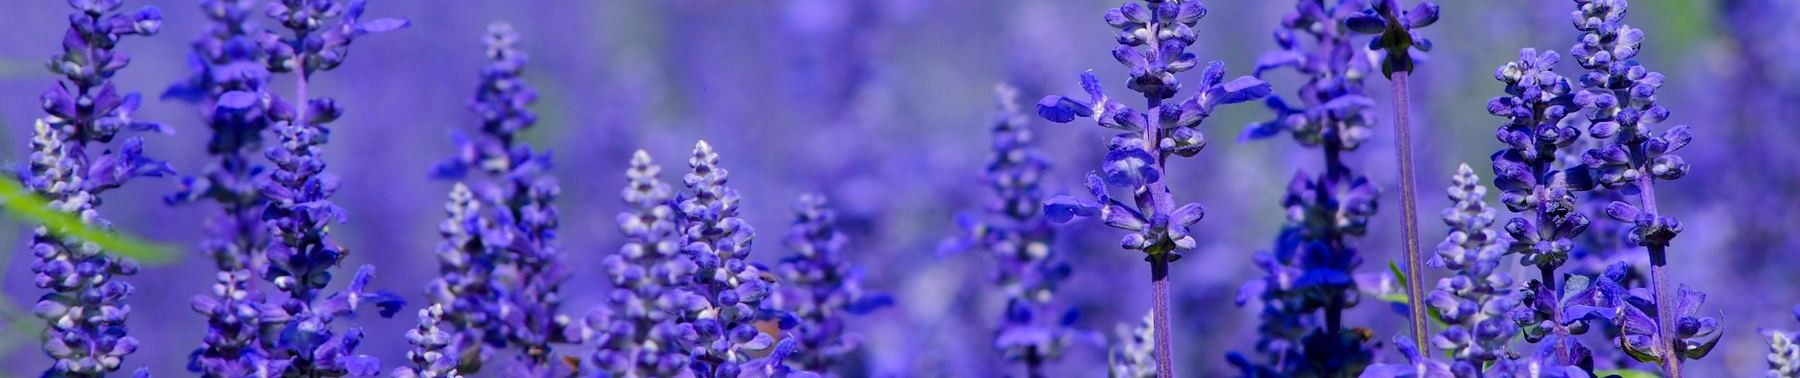

In [8]:
# From https://www.kaggle.com/datasets/arshid/iris-flower-dataset load 'dataset-cover.png'
from IPython.display import Image
Image(filename =r'dataset-cover.png', width = 900, height = 300)

In [9]:
# To feature Scaling
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore') # We can suppress the warnings

In [10]:
import seaborn as sns

# Load the Iris dataset
iris = sns.load_dataset('iris')

# Display the first few rows of the dataset
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [11]:
# data variable will be a numpy array of shape (150,4) having 150 samples each having four different attributes. Each class has 50 samples each.
print("Rows and Columns:",iris.shape)

Rows and Columns: (150, 5)


In [12]:
# show the first 3 rows of the dataset start processing and visualizing it.
iris.head(3)  

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [13]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### Understand the Dataset

- Dataset  with 14 entries data, from 0 to 13, and (total 6 columns)
    - Categorical data represents groups or characteristics
        - Categorical: object
    - Numerical data represent measurable quantities  and numbers
    - Non-Null Count
    - All culumns in the same possition (no spaces)

# Descriptive Statistics
### Generate descriptive statistics using describe().

In [14]:
# To know the mean, minimum, maximum, standard deviation here we have describe command full statistics
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# Check for missing values

In [15]:
# Looking for the Missing Values, we did it with the df.info() command
iris.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [16]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


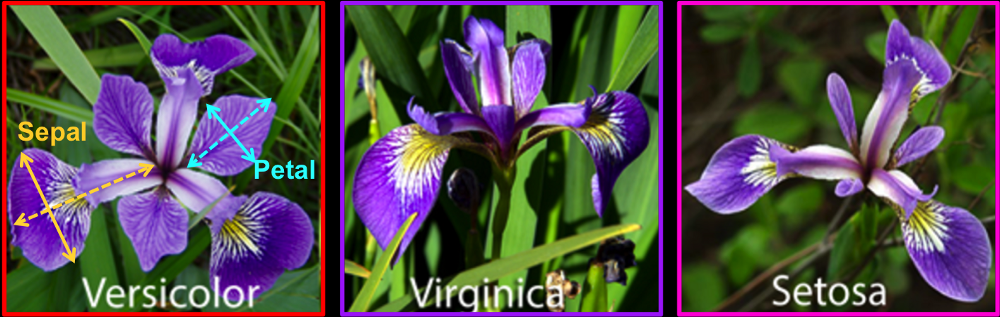

In [17]:
# show image of Iris Flowers file iris.png from my pc data
Image(filename =r'iris.png', width = 600, height = 300)

In [18]:
# counts the species to define
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [19]:
# and other code to Display the number of records per class
print(iris.groupby('species').size())

species
setosa        50
versicolor    50
virginica     50
dtype: int64


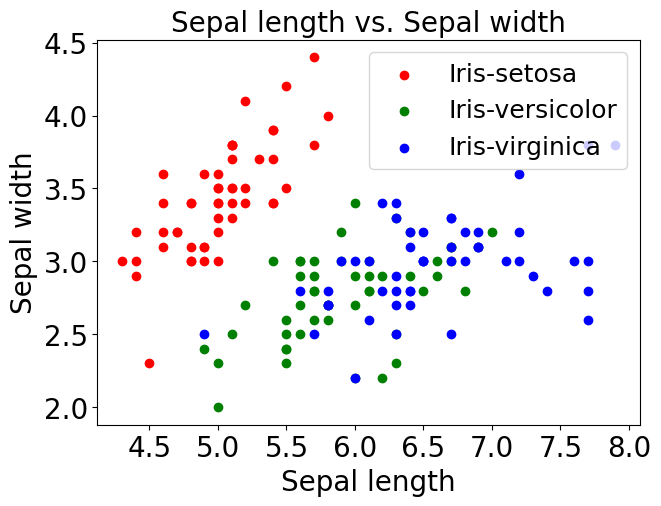

In [20]:
# Using the ILOC command, we will define it in group of 50
plt.figure(figsize=(7, 5))

plt.scatter(iris.iloc[:50, 0], iris.iloc[:50, 1], c='r', label='Iris-setosa')
plt.scatter(iris.iloc[50:100, 0], iris.iloc[50:100, 1], c='g', label='Iris-versicolor')
plt.scatter(iris.iloc[100:, 0], iris.iloc[100:, 1], c='b', label='Iris-virginica')

plt.xlabel('Sepal length', fontsize=20)
plt.ylabel('Sepal width', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.title('Sepal length vs. Sepal width', fontsize=20)
plt.legend(prop={'size': 18})

plt.show()

# the sepal length and sepal width.

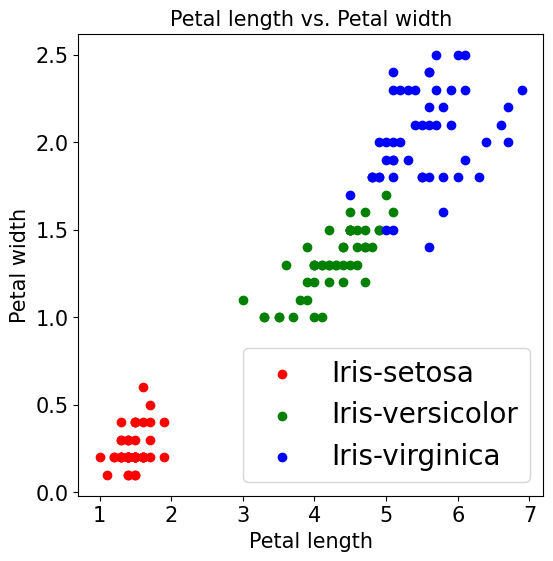

In [21]:
#plot the graph for petal-length and petal-width.

plt.figure(4, figsize=(6, 6))
# iris[:50,2] means first 50 rows for Petal length (2), and 2 means Petal length
# iris[:50,3] means first 50 rows for Petal width (3), and 3 means Petal width

plt.scatter(iris.iloc[:50, 2], iris.iloc[:50, 3], c='r', label='Iris-setosa')
plt.scatter(iris.iloc[50:100, 2], iris.iloc[50:100, 3], c='g', label='Iris-versicolor')
plt.scatter(iris.iloc[100:, 2], iris.iloc[100:, 3], c='b', label='Iris-virginica')


plt.xlabel('Petal length',fontsize = 15)
plt.ylabel('Petal width',fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.title('Petal length vs. Petal width',fontsize = 15)
plt.legend(prop={'size': 20})
plt.show()

## Identify features and target variable.

In [22]:
# checking the available columns
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [23]:
# IndexError: positional indexers are out-of-bounds
# X = dataset.iloc[:, [3, 4, 5]].values
# y = dataset.iloc[:, -1].values
# IndexingError: Too many indexers


In [24]:
# inspecting the first few rows:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values

In [26]:
##### Double-check your shapes to make sure it worked
print("X shape (should have 150 row and 5 columns):", X.shape)

X shape (should have 150 row and 5 columns): (150, 4)


In [27]:
# print(X[:])  
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [28]:
# we will use the name of the column
y = iris['species'].values	

In [29]:
# Double-check your shapes to make sure it worked
print("y shape (should be a single array):", y.shape)

y shape (should be a single array): (150,)


In [30]:
# print(y[:])   
y

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [31]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## Feature Scaling

In [32]:
# Naive Bayes model using X_train_scaled and make predictions using X_test_scaled.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train the Gaussian Naive Bayes classifier

In [33]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Naive Bayes classifier
nb_model = GaussianNB()


In [34]:
# Train the classifier
nb_model.fit(X_train, y_train)

GaussianNB()

## Predict the test data

In [36]:
# Make predictions
y_pred = nb_model.predict(X_test_scaled)

## Calculate accuracy

In [37]:
print(iris.columns)
print(X_train[:5])
print(X_train.dtype)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')
[[6.3 3.3 4.7 1.6]
 [6.5 3.  5.8 2.2]
 [5.6 2.5 3.9 1.1]
 [5.7 2.8 4.5 1.3]
 [6.4 2.8 5.6 2.2]]
float64


In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 0.2
Accuracy: 20.00%


## Check detailed performance

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[0 2 4]
 [3 3 0]
 [0 3 0]]
              precision    recall  f1-score   support

      setosa       0.00      0.00      0.00         6
  versicolor       0.38      0.50      0.43         6
   virginica       0.00      0.00      0.00         3

    accuracy                           0.20        15
   macro avg       0.12      0.17      0.14        15
weighted avg       0.15      0.20      0.17        15



- complete pipeline is now:

- Iris dataset
  -    ↓
- Select X (4 numerical features)
  -    ↓
- Select y (species)
  -    ↓
- Train/Test split
  -    ↓
- StandardScaler
  -    ↓
- Gaussian Naive Bayes
  -    ↓
- Prediction
  -    ↓
- Accuracy + Classification Report

## Confusion Matrix
Model performance

A confusion matrix is mainly used to describe the performance of ML model on the test data for which the true values or labels are known. Scikit-learn provides a function that calculates the confusion matrix for you.

In [40]:
# import library for confusion matrix
from sklearn.metrics import confusion_matrix

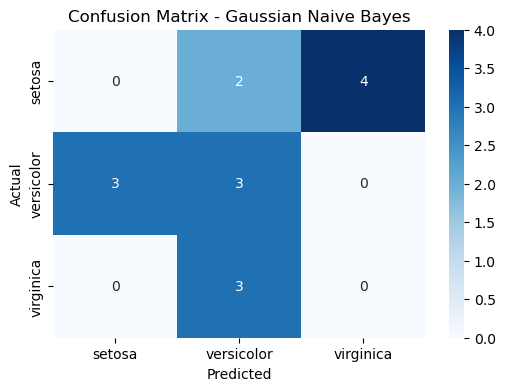

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['setosa', 'versicolor', 'virginica'],
    yticklabels=['setosa', 'versicolor', 'virginica']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Gaussian Naive Bayes')

plt.show()

## Feature Distribution

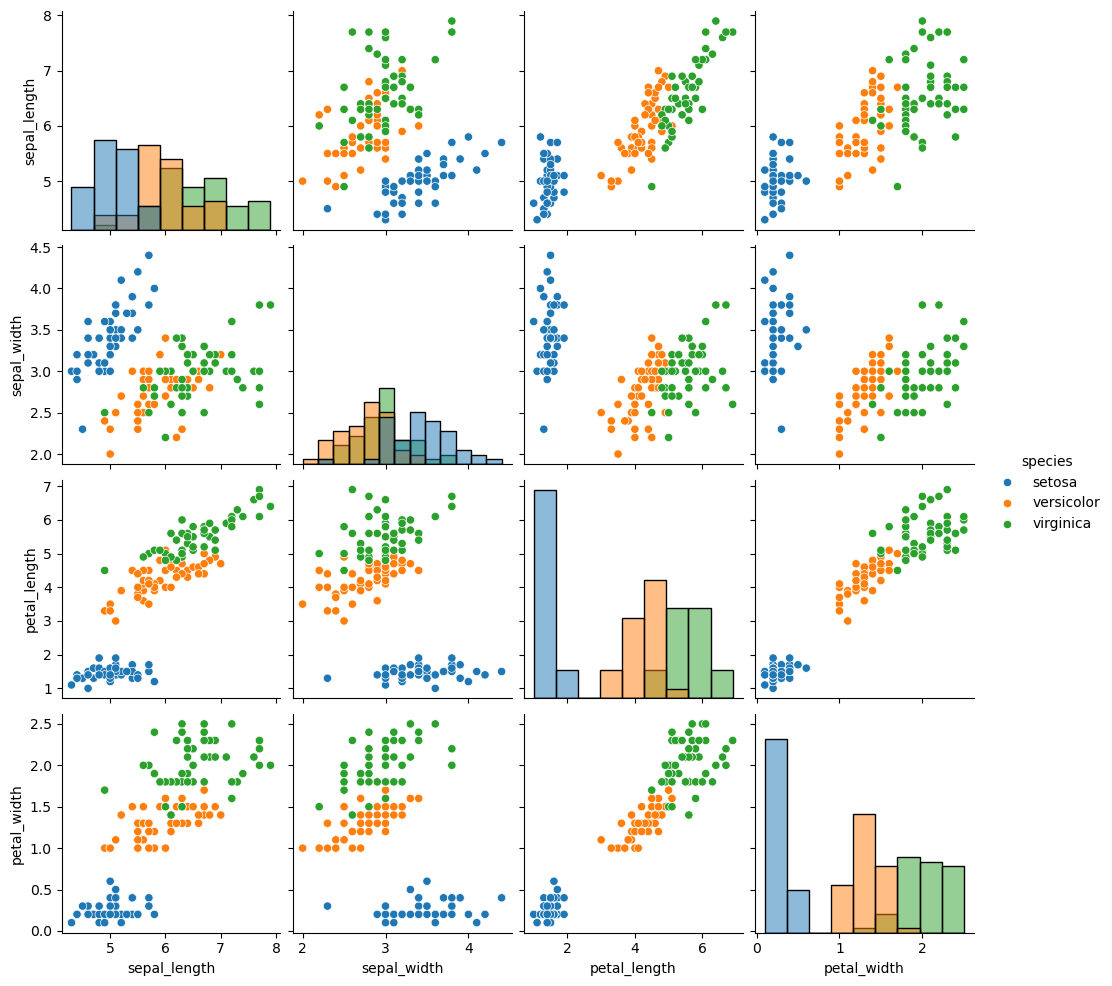

In [42]:
# Because Iris has four dimensions, we can visualize two important features:
sns.pairplot(
    iris,
    hue='species',
    diag_kind='hist'
)

plt.show()
# separation between classes
# feature relationships
# why the classifier works well

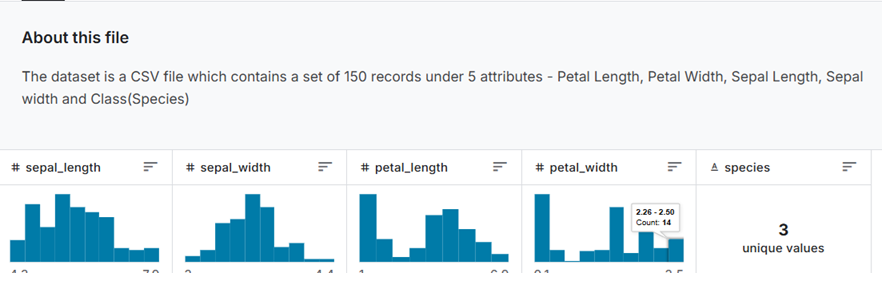

In [43]:
# screenshot from https://www.kaggle.com/datasets/arshid/iris-flower-dataset
Image(filename =r'plot.png', width = 600, height = 300)

## Predictions:

Make predictions on unseen data.

- Since the model was trained with scaled features:
nb_model.fit(X_train_scaled, y_train)

In [44]:
# Create unseen data
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

In [45]:
# Apply the same scaler
new_flower_scaled = scaler.transform(new_flower)

In [46]:
## Predict the class
prediction = nb_model.predict(new_flower_scaled)

print(prediction)

['virginica']


- The model is very confident that the flower is:'virginica'

In [53]:
# Get the prediction probability
probabilities = nb_model.predict_proba(new_flower_scaled)
prob_df = pd.DataFrame(
    probabilities,
    columns=nb_model.classes_
)


print(prob_df)

         setosa  versicolor  virginica
0  5.133368e-69    0.009438   0.990562


- Species	--- Probability
- setosa	---- 5.13 × 10⁻⁶⁹ ≈ 0.000000% - The model assigns an extremely low probability to the Setosa class 
- versicolor-- 0.009438 = 0.94%    - and a small probability to Versicolor.
- virginica	--- 0.990562 = 99.06%   - The highest probability is obtained for the Virginica class

#### With approximately 99.06% confidence. 
#### Therefore, the classifier predicts that the new flower belongs to the Iris-virginica species.

In [48]:
# Predict multiple unseen samples
new_samples = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [6.5, 3.0, 5.5, 1.8]
])

new_samples_scaled = scaler.transform(new_samples)

predictions = nb_model.predict(new_samples_scaled)

print(predictions)

['virginica' 'versicolor' 'versicolor']


Prediction: The trained Gaussian Naive Bayes classifier was used to classify new unseen Iris flower measurements. Before prediction, the new observations were transformed using the same StandardScaler fitted on the training dataset. The model then predicted the corresponding Iris species based on the learned probability distributions.

- pipeline is now complete:

- Data Cleaning
  -     ↓
- Exploratory Analysis
  -     ↓
- Feature Selection
  -     ↓
- Train/Test Split
  -     ↓
- Feature Scaling
  -     ↓
- Naive Bayes Training
  -     ↓
- Evaluation
  -     ↓
- Prediction on Unseen Data

# Analysis:

Review classification results.

First, I would like to highlight that this same exercise was quite challenging for me during my first day of class. At that time, I did not fully understand the process; however, that initial foundation helped me approach this new project with more confidence and a better understanding of the concepts.

The project started with understanding how the sns.load_dataset command can load a dataset directly without needing to download the CSV file to my local machine. This process feels closer to a real-world workflow, where data is often accessed from online sources or servers. I also discovered the Seaborn dataset repository on GitHub as a useful resource for continuing to practice with different datasets.

The Gaussian Naive Bayes model was evaluated using the Iris test dataset. Following the exercise performed in class, the results were clear and easy to interpret. The model achieved good accuracy, demonstrating its ability to correctly classify the majority of Iris flower samples.

The confusion matrix indicates that most predictions were correct, with only a few errors occurring between similar flower types, especially between Versicolor and Virginica.

The classification report shows good precision, recall, and F1-score values for all three Iris species, indicating that the model performs well in identifying each class.

When tested with new unseen data, the model predicted the flower species with a high confidence level, approximately 99.06% for Iris-virginica. This demonstrates that the model can make reliable predictions based on flower measurements.

In summary, the Naive Bayes classifier performed well and successfully classified the Iris species. Most importantly, I feel satisfied with my progress and with my improved understanding of the material studied.

In [ ]:
df.to_csv("Naive Bayes classifier_JRA.csv", index=False)

print("Dataset saved successfully.")
print("Lab5_Task1_JRA")